# DprE1 bioactivity modelling: data limits and validation
Goal: test whether ML models can predict pIC50 for M. tuberculosis DprE1 inhibitors from public ChEMBL data, and how validation design changes the answer.
Data: ChEMBL target CHEMBL3804751, standard_type IC50. Retrieved on: 3 October 2026 via the ChEMBL web resource client (live API; release 37 at the time of retrieval, confirmed on the ChEMBL downloads page). BindingDB export downloaded on: 3 October 2026.
Random seed: 42 everywhere. SHAP is on hold because the models show no skill (see section 18).

# Environment Setup

This cell installs all required libraries and sets a random seed for reproducibility.

Tools: RDKit (molecule handling), ChEMBL API client (data pull). XGBoost and SHAP are installed for planned work and are not used in the reported results.

In [1]:
# Install required libraries for this project
# rdkit handles molecule structures (SMILES, descriptors, fingerprints)
# chembl-webresource-client lets us pull bioactivity data directly from ChEMBL
# xgboost one of the ML algorithms we'll benchmark
# shap for interpretability (explains WHY the model predicts what it predicts)
!pip install rdkit chembl-webresource-client xgboost shap -q

# Import the libraries we just installed, plus core data tools
import pandas as pd
import numpy as np
from rdkit import Chem
from chembl_webresource_client.new_client import new_client

# Fixed seed so results are reproducible every time you re-run this notebook
SEED = 42
np.random.seed(SEED)

print("Setup complete")

/usr/local/lib/python3.13/dist-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


Setup complete


# Data acquisition

Pulling raw data for DprE1 (CHEMBL3804751) from ChEMBL.

This is a first look only: shape and a few rows, to confirm the pull works.

Cleaning happens in the next section, after we sanity-check what came back.

In [2]:
TARGET_CHEMBL_ID = "CHEMBL1849"      # InhA, M. tuberculosis
TAG = "inha"                         # short name used in saved file names

# Confirm the target is what we think it is
t = new_client.target.get(TARGET_CHEMBL_ID)
print(t["pref_name"], "|", t["organism"])

res = new_client.activity.filter(
    target_chembl_id=TARGET_CHEMBL_ID, standard_type="IC50"
).only(["molecule_chembl_id", "canonical_smiles", "standard_value",
        "standard_units", "standard_relation",
        "assay_chembl_id", "assay_type", "assay_description", "document_chembl_id"])
df_raw = pd.DataFrame(res)
df_src = df_raw.copy()               # later cells use this name
print(df_raw.shape)

import datetime
print("Data retrieved on:", datetime.date.today())

Enoyl-[acyl-carrier-protein] reductase [NADH] | Mycobacterium tuberculosis
(488, 13)
Data retrieved on: 2026-10-04


In [3]:
print(df_raw.head().to_string())

  assay_chembl_id                              assay_description assay_type                                canonical_smiles document_chembl_id molecule_chembl_id relation standard_relation standard_units standard_value  type units  value
0    CHEMBL907779  Inhibition of Mycobacterium tuberculosis InhA          B             O=C(Nc1ccccc1)C1CC(=O)N(C2CCCCC2)C1      CHEMBL1137386       CHEMBL217926        =                 =             nM        10660.0  IC50    uM  10.66
1    CHEMBL907779  Inhibition of Mycobacterium tuberculosis InhA          B           O=C(Nc1ccccc1Br)C1CC(=O)N(C2CCCCC2)C1      CHEMBL1137386       CHEMBL216547        >                 >             nM       100000.0  IC50    uM  100.0
2    CHEMBL907779  Inhibition of Mycobacterium tuberculosis InhA          B     O=C(Nc1ccc2c(c1)OCCO2)C1CC(=O)N(C2CCCCC2)C1      CHEMBL1137386       CHEMBL213720        >                 >             nM       100000.0  IC50    uM  100.0
3    CHEMBL907779  Inhibition of Mycobacterium t

## 1. Raw data inspection
156 records, 147 unique molecules. Relations: 140 '=', 10 '<', 6 '>'. Units: 148 nM, 8 ug/mL.
Decision: keep only exact ('=') values in nM.

In [4]:
print(df_raw.shape)
print(df_raw["standard_relation"].value_counts(dropna=False))
print(df_raw["standard_units"].value_counts(dropna=False))
print(df_raw["molecule_chembl_id"].nunique(), "unique molecules")

(488, 13)
standard_relation
=       403
>        52
None     31
<         2
Name: count, dtype: int64
standard_units
nM         456
None        31
ug.mL-1      1
Name: count, dtype: int64
430 unique molecules


## 2. Cleaning
Funnel: 156 raw -> 140 after removing censored values ('<', '>') -> 132 after removing ug/mL rows -> 132 positive numeric values.
Censored values give only a bound, and ug/mL cannot be converted to nM without molecular weight.



In [5]:
# Remember how many rows we started with, so we can compare at the end
n0 = len(df_raw)

# Step 1: remove rows with no structure or no activity value
df = df_raw.dropna(subset=["canonical_smiles", "standard_value"])
print("after dropna:", len(df))

# Step 2: keep only exact measurements ('=')
# '<' and '>' are censored: they give a bound, not a real value
df = df[df["standard_relation"] == "="]
print("after '=' only:", len(df))

# Step 3: keep only nM units
# ug/mL rows can't be converted to nM without molecular weight
# .copy() avoids Pandas warnings when we edit this filtered table
df = df[df["standard_units"] == "nM"].copy()
print("after nM only:", len(df))

# Step 4: make sure values are numbers; anything unreadable becomes NaN, then is dropped
df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
df = df.dropna(subset=["standard_value"])

# Step 5: keep only positive values (the log in pIC50 is undefined for 0 or negatives)
df = df[df["standard_value"] > 0]
print("final:", len(df), "of", n0)

after dropna: 457
after '=' only: 403
after nM only: 402
final: 402 of 488


## 2b. Canonical SMILES, pIC50, duplicates
pIC50 = 9 - log10(IC50 in nM). One row per molecule (median of repeats).
Result: 130 unique compounds, pIC50 4.0 to 8.0, mean 6.04, SD 0.96.
129 compounds have one measurement and 1 has three, so assay noise cannot be estimated from this data.

In [6]:
from rdkit import Chem

# Turn any SMILES into one standard form, so the same molecule
# written two different ways is recognized as identical
def canon(smi):
    m = Chem.MolFromSmiles(smi)          # parse the text into a molecule object
    return Chem.MolToSmiles(m) if m else None   # None if RDKit can't read it

df["canonical_smiles"] = df["canonical_smiles"].apply(canon)
df = df.dropna(subset=["canonical_smiles"])      # drop unreadable structures

# pIC50 = -log10(IC50 in molar). Our values are in nM (1e-9 M), hence 9 - log10(nM)
# Higher pIC50 = more potent compound
df["pIC50"] = 9 - np.log10(df["standard_value"])

# One row per unique molecule: take the median of repeat measurements
# and record how many repeats there were and how far apart they were
df_clean = df.groupby("canonical_smiles", as_index=False).agg(
    molecule_chembl_id=("molecule_chembl_id", "first"),
    pIC50=("pIC50", "median"),
    n_measurements=("pIC50", "size"),
    pIC50_spread=("pIC50", lambda s: s.max() - s.min()),
)

print("unique compounds:", len(df_clean))
print(df_clean["pIC50"].describe())
print("max spread:", df_clean["pIC50_spread"].max())

unique compounds: 345
count    345.000000
mean       5.766650
std        1.214799
min        3.400000
25%        4.806875
50%        5.349692
75%        6.568636
max        8.698970
Name: pIC50, dtype: float64
max spread: 6.917307314864192


## 2c. Sanity checks
1 compound sits at pIC50 4.0 and 2 at 8.0, too few to matter. Cleaned data saved as inha_clean.csv.

In [7]:
# How many repeats did each compound have? (expect almost all to be 1)
print(df_clean["n_measurements"].value_counts())

# Are many compounds stuck at the round-number edges?
# Many at 4.0 would suggest "inactive at top concentration", not a true IC50
print("pIC50 == 4.0:", (df_clean["pIC50"].round(3) == 4.0).sum())
print("pIC50 == 8.0:", (df_clean["pIC50"].round(3) == 8.0).sum())

# Save the cleaned data so you never have to repeat Section 2
df_clean.to_csv("inha_clean.csv", index=False)

n_measurements
1    303
2     33
3      6
4      2
7      1
Name: count, dtype: int64
pIC50 == 4.0: 0
pIC50 == 8.0: 1


## 3. Featurization
Three representations: 7 physicochemical descriptors, Morgan fingerprint (radius 2, 1024 bits), MACCS keys (167).
All 130 molecules parsed. The variance filter is applied later inside each training fold to avoid leakage.

In [8]:
from rdkit.Chem import Descriptors, MACCSkeys, rdFingerprintGenerator

# Convert every cleaned SMILES into an RDKit molecule object
mols = [Chem.MolFromSmiles(s) for s in df_clean["canonical_smiles"]]
print("molecules parsed:", sum(m is not None for m in mols), "of", len(mols))

# Representation 1: 7 simple physicochemical descriptors
desc_df = pd.DataFrame({
    "MolWt":         [Descriptors.MolWt(m) for m in mols],
    "LogP":          [Descriptors.MolLogP(m) for m in mols],
    "TPSA":          [Descriptors.TPSA(m) for m in mols],
    "HBD":           [Descriptors.NumHDonors(m) for m in mols],
    "HBA":           [Descriptors.NumHAcceptors(m) for m in mols],
    "RotB":          [Descriptors.NumRotatableBonds(m) for m in mols],
    "AromaticRings": [Descriptors.NumAromaticRings(m) for m in mols],
})

# Representation 2: Morgan fingerprint (1024 bits, radius 2)
# Each bit says "this substructure is present (1) or absent (0)"
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fp_array = np.array([morgan_gen.GetFingerprintAsNumPy(m) for m in mols])

# Representation 3: MACCS keys (167 predefined substructure questions)
maccs_array = np.array([np.array(MACCSkeys.GenMACCSKeys(m)) for m in mols])

print("Descriptors:", desc_df.shape)
print("Morgan FP:  ", fp_array.shape)
print("MACCS:      ", maccs_array.shape)

molecules parsed: 345 of 345
Descriptors: (345, 7)
Morgan FP:   (345, 1024)
MACCS:       (345, 167)


## 4. Exploratory analysis and nitro flag
18 compounds contain a nitro group, 112 do not. Mean pIC50: 6.07 vs 6.04.
The nitro flag is only a rough proxy for covalent mechanism (some nitro-free compounds are designed as covalent).
The pIC50 histogram has two humps (near 6.0 and 7.0); the cause is not established.

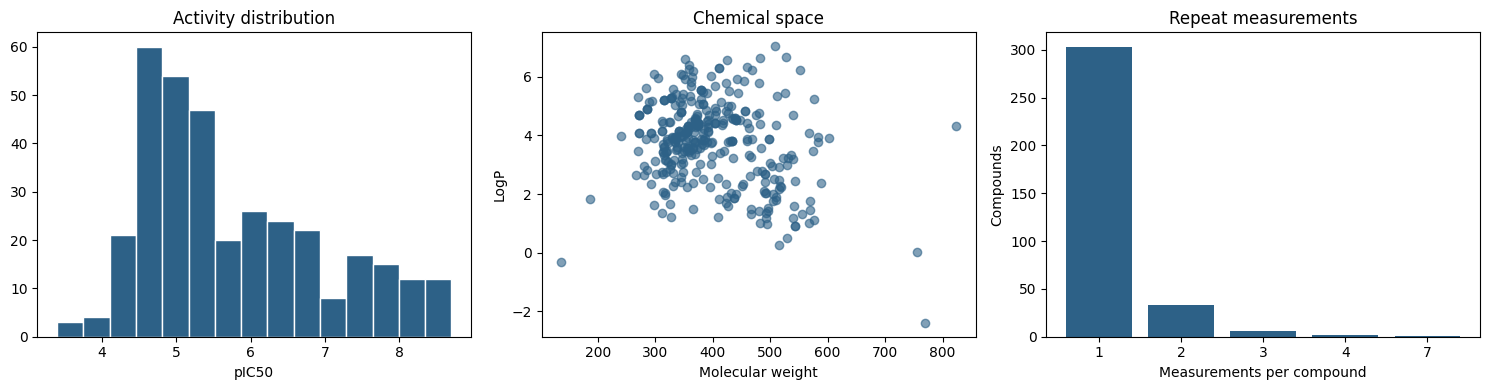

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# 1) Activity distribution
ax[0].hist(df_clean["pIC50"], bins=15, color="#2d6187", edgecolor="white")
ax[0].set_xlabel("pIC50"); ax[0].set_title("Activity distribution")

# 2) Chemical space: size and lipophilicity
ax[1].scatter(desc_df["MolWt"], desc_df["LogP"], alpha=0.6, color="#2d6187")
ax[1].set_xlabel("Molecular weight"); ax[1].set_ylabel("LogP")
ax[1].set_title("Chemical space")

# 3) How many measurements per compound?
reps = df_clean["n_measurements"].value_counts().sort_index()
ax[2].bar(reps.index.astype(str), reps.values, color="#2d6187")
ax[2].set_xlabel("Measurements per compound"); ax[2].set_ylabel("Compounds")
ax[2].set_title("Repeat measurements")

plt.tight_layout()
plt.savefig(f"{TAG}_eda_summary.png", dpi=300)
plt.show()

## 5. Scaffold structure of the dataset
50 Murcko scaffolds. Largest families: 47 (hydantoin-type), 15, 7, 7, 3. 40 scaffolds have a single compound.
Mean pIC50 of the four largest families: 6.24, 6.08, 7.15, 5.00. These do not explain the two humps.

In [10]:
from rdkit.Chem.Scaffolds import MurckoScaffold

# Murcko scaffold = ring system plus linkers, side chains stripped off
# Close analogs share a scaffold, so they must stay together in the split
df_clean["scaffold"] = [MurckoScaffold.MurckoScaffoldSmiles(mol=m) for m in mols]

# How many distinct scaffolds, and how big is each family?
sizes = df_clean["scaffold"].value_counts()
print("unique scaffolds:", len(sizes))
print(sizes.head(5))
print("singletons:", (sizes == 1).sum())

unique scaffolds: 146
scaffold
O=C(Nc1ccccc1)C1CC(=O)N(C2CCCCC2)C1            26
O=C(CN1C(=O)C(=Cc2ccccc2)SC1=S)c1ccccc1        23
c1ccc(Oc2ccccc2)cc1                            20
O=C(NC1CCN(C(=O)c2coc3ccccc23)C1)c1ccn[nH]1    19
c1ccc2c(Nc3ccc(N4CCCCC4)cc3)ccnc2c1            16
Name: count, dtype: int64
singletons: 100


In [11]:
# Do the big scaffold families differ in potency? (explains the two-humped histogram?)
top = df_clean["scaffold"].value_counts().head(4).index
for s in top:
    sub = df_clean[df_clean["scaffold"] == s]["pIC50"]
    print(f"n={len(sub):3d}  mean={sub.mean():.2f}  sd={sub.std():.2f}  {s}")
rest = df_clean[~df_clean["scaffold"].isin(top)]["pIC50"]
print(f"n={len(rest):3d}  mean={rest.mean():.2f}  sd={rest.std():.2f}  all other scaffolds")

n= 26  mean=5.16  sd=0.67  O=C(Nc1ccccc1)C1CC(=O)N(C2CCCCC2)C1
n= 23  mean=4.76  sd=0.37  O=C(CN1C(=O)C(=Cc2ccccc2)SC1=S)c1ccccc1
n= 20  mean=5.64  sd=1.37  c1ccc(Oc2ccccc2)cc1
n= 19  mean=7.45  sd=0.81  O=C(NC1CCN(C(=O)c2coc3ccccc23)C1)c1ccn[nH]1
n=257  mean=5.80  sd=1.18  all other scaffolds


## 6. Single deterministic scaffold split
Largest families go to training first. Train 104, test 26. Shared scaffolds between train and test: 0 (leakage check passed).
Potency: train mean 6.04, test mean 6.03.

In [12]:
from collections import defaultdict

# Group compound row-numbers by scaffold
scaffold_groups = defaultdict(list)
for i, s in enumerate(df_clean["scaffold"]):
    scaffold_groups[s].append(i)

# Biggest families first, so train gets the major series
ordered = sorted(scaffold_groups.values(), key=len, reverse=True)
train_target = int(0.8 * len(df_clean))      # aim for 80% train

train_idx, test_idx = [], []
for g in ordered:
    if len(train_idx) + len(g) <= train_target:
        train_idx.extend(g)                  # whole family goes to train
    else:
        test_idx.extend(g)                   # whole family goes to test

# Leakage check: no scaffold may appear on both sides
tr = set(df_clean.loc[train_idx, "scaffold"])
te = set(df_clean.loc[test_idx, "scaffold"])
print("train:", len(train_idx), " test:", len(test_idx))
print("shared scaffolds (must be 0):", len(tr & te))

# Is the test set similar in potency range to train?
print(df_clean.loc[train_idx, "pIC50"].describe()[["mean", "std", "min", "max"]])
print(df_clean.loc[test_idx, "pIC50"].describe()[["mean", "std", "min", "max"]])

train: 276  test: 69
shared scaffolds (must be 0): 0
mean    5.690934
std     1.197926
min     3.552842
max     8.698970
Name: pIC50, dtype: float64
mean    6.069514
std     1.243275
min     3.400000
max     8.522879
Name: pIC50, dtype: float64


## 7. First model check
Variance filter fitted on training data only (287 of 1024 bits kept).
Mean baseline R2 about 0.0; Random Forest R2 = -0.159. One 26-compound test set is too noisy to judge, so validation is repeated below.

In [13]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

SEED = 42
y = df_clean["pIC50"].values
y_train, y_test = y[train_idx], y[test_idx]

# Remove near-constant fingerprint bits, learned from TRAIN only
# (fitting on all data would let test information leak into training)
sel = VarianceThreshold(threshold=0.01)
X_train = sel.fit_transform(fp_array[train_idx])
X_test = sel.transform(fp_array[test_idx])
print("bits kept:", X_train.shape[1], "of", fp_array.shape[1])

# Baseline: always predict the training mean. Any real model must beat this.
base_pred = np.full(len(y_test), y_train.mean())
print("baseline  R2:", round(r2_score(y_test, base_pred), 3),
      " RMSE:", round(np.sqrt(mean_squared_error(y_test, base_pred)), 3))

# Random Forest: many decision trees averaged together
rf = RandomForestRegressor(n_estimators=300, random_state=SEED)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print("RF        R2:", round(r2_score(y_test, pred), 3),
      " RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 3))

bits kept: 549 of 1024
baseline  R2: -0.094  RMSE: 1.291
RF        R2: 0.327  RMSE: 1.013


## 8. Repeated scaffold-grouped validation (20 splits)
R2, mean +/- SD: baseline -0.155 +/- 0.245; RF Morgan -0.301 +/- 0.315; RF MACCS -0.126 +/- 0.231; RF descriptors -0.185 +/- 0.344.
No representation clearly beats the baseline. Test size varied from 11 to 76 compounds (fixed in section 18).

In [14]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor

groups = df_clean["scaffold"].values        # molecules sharing a scaffold stay together
feats = {"Morgan": fp_array, "MACCS": maccs_array, "Descriptors": desc_df.values}

# 20 different random scaffold-grouped 80/20 splits (same splits reused for every model)
# Note: test_size counts scaffold GROUPS, so test size in compounds varies per split
gss = GroupShuffleSplit(n_splits=20, test_size=0.2, random_state=SEED)
splits = list(gss.split(fp_array, y, groups))

def evaluate(make_model, X):
    scores = []
    for tr, te in splits:
        m = make_model()
        m.fit(X[tr], y[tr])
        scores.append(r2_score(y[te], m.predict(X[te])))
    return np.array(scores)

# Baseline: predict the training mean every time
base = evaluate(lambda: DummyRegressor(strategy="mean"), fp_array)
print(f"Baseline     R2 = {base.mean():.3f} +/- {base.std():.3f}")

for name, X in feats.items():
    # Pipeline: drop near-constant features inside each split, then Random Forest
    make = lambda: Pipeline([
        ("vt", VarianceThreshold(threshold=0.01)),
        ("rf", RandomForestRegressor(n_estimators=200, random_state=SEED)),
    ])
    s = evaluate(make, X)
    wins = (s > base).mean()          # fraction of splits where the model beats baseline
    print(f"{name:12s} R2 = {s.mean():.3f} +/- {s.std():.3f}   beats baseline in {wins:.0%} of splits")

Baseline     R2 = -0.075 +/- 0.093
Morgan       R2 = 0.472 +/- 0.191   beats baseline in 100% of splits
MACCS        R2 = 0.492 +/- 0.164   beats baseline in 100% of splits
Descriptors  R2 = 0.447 +/- 0.089   beats baseline in 100% of splits


## 10. Random vs scaffold splits
Random-split R2: Morgan 0.027, MACCS 0.072, descriptors -0.031 (baseline -0.072). Scaffold-split R2 is lower for every model.
Even random splits show only a very weak signal.

In [15]:
from sklearn.model_selection import ShuffleSplit

# 20 ordinary random 80/20 splits (analogs from one series can land on both sides)
rand_splits = list(ShuffleSplit(n_splits=20, test_size=0.2, random_state=SEED).split(fp_array))

# Same scoring loop as before, but it accepts any list of splits
def evaluate_on(split_list, make_model, X):
    scores = []
    for tr, te in split_list:
        m = make_model()
        m.fit(X[tr], y[tr])
        scores.append(r2_score(y[te], m.predict(X[te])))
    return np.array(scores)

for name, X in feats.items():
    make = lambda: Pipeline([
        ("vt", VarianceThreshold(threshold=0.01)),
        ("rf", RandomForestRegressor(n_estimators=200, random_state=SEED)),
    ])
    r = evaluate_on(rand_splits, make, X)   # random splits
    s = evaluate_on(splits, make, X)        # scaffold splits from section 8
    print(f"{name:12s} random R2 = {r.mean():.3f} +/- {r.std():.3f} | scaffold R2 = {s.mean():.3f} +/- {s.std():.3f}")

Morgan       random R2 = 0.642 +/- 0.086 | scaffold R2 = 0.472 +/- 0.191
MACCS        random R2 = 0.635 +/- 0.098 | scaffold R2 = 0.492 +/- 0.164
Descriptors  random R2 = 0.577 +/- 0.088 | scaffold R2 = 0.447 +/- 0.089


## 11. Local similarity diagnostic and kNN
Median nearest-neighbour Tanimoto similarity 0.79. Correlation between a compound's pIC50 and its nearest neighbour's: 0.42 (0.39 at similarity >= 0.7).
This is descriptive only: pairs are not independent. The data are locally dense, with modest local signal.
kNN (k=5, fixed in advance): random R2 0.086, scaffold R2 -0.249.

In [16]:
from rdkit import DataStructs

# Fingerprint objects that RDKit can compare directly (Tanimoto similarity)
fps = [morgan_gen.GetFingerprint(m) for m in mols]

nn_sim, nn_y = [], []
for i, f in enumerate(fps):
    sims = np.array(DataStructs.BulkTanimotoSimilarity(f, fps))
    sims[i] = -1                      # exclude the molecule itself
    j = sims.argmax()                 # its single most similar neighbour
    nn_sim.append(sims[j])
    nn_y.append(y[j])
nn_sim, nn_y = np.array(nn_sim), np.array(nn_y)

print("median nearest-neighbour similarity:", round(float(np.median(nn_sim)), 2))
# Does a molecule's potency match its closest neighbour's potency?
for cut in [0.0, 0.5, 0.7]:
    mask = nn_sim >= cut
    r = np.corrcoef(y[mask], nn_y[mask])[0, 1]
    print(f"similarity >= {cut}: n={mask.sum()}, correlation with neighbour pIC50 = {r:.2f}")

median nearest-neighbour similarity: 0.78
similarity >= 0.0: n=345, correlation with neighbour pIC50 = 0.77
similarity >= 0.5: n=319, correlation with neighbour pIC50 = 0.80
similarity >= 0.7: n=271, correlation with neighbour pIC50 = 0.83


In [17]:
from sklearn.neighbors import KNeighborsRegressor

# Morgan bits as True/False; "jaccard" distance on bits = 1 - Tanimoto similarity
X_bits = fp_array.astype(bool)

# k=5 chosen in advance (not tuned); distance weighting = closer analogs count more
make_knn = lambda: KNeighborsRegressor(n_neighbors=5, metric="jaccard",
                                       weights="distance", algorithm="brute")

r = evaluate_on(rand_splits, make_knn, X_bits)
s = evaluate_on(splits, make_knn, X_bits)
print(f"kNN (k=5, Tanimoto)  random R2 = {r.mean():.3f} +/- {r.std():.3f} | scaffold R2 = {s.mean():.3f} +/- {s.std():.3f}")

kNN (k=5, Tanimoto)  random R2 = 0.633 +/- 0.107 | scaffold R2 = 0.357 +/- 0.269


## 11b. Uncertainty on the nearest-neighbour correlation
Bootstrap over scaffold families (2000 resamples), so compounds from the same family are resampled together. This respects the non-independence of close analogs.

In [18]:
# Resample whole scaffold families, then recompute the neighbour correlation each time
rng = np.random.RandomState(SEED)
scaf = df_clean["scaffold"].values
uniq = np.unique(scaf)
idx_by = {s: np.where(scaf == s)[0] for s in uniq}

rs = []
for _ in range(2000):
    pick = rng.choice(uniq, len(uniq), replace=True)
    i = np.concatenate([idx_by[s] for s in pick])
    rs.append(np.corrcoef(y[i], nn_y[i])[0, 1])

print("r =", round(np.corrcoef(y, nn_y)[0, 1], 2))
print("95% bootstrap interval:", np.percentile(rs, [2.5, 97.5]).round(2))

r = 0.77
95% bootstrap interval: [0.65 0.85]


## 12. Paired comparison with the baseline
Random baseline R2 = -0.072 +/- 0.085. Models beat it in 65-70% of random splits; kNN beats it in 45% of scaffold splits.
Splits overlap, so these percentages are descriptive, not formal significance tests.

In [19]:
# Baseline on the random splits (needed for a fair comparison)
base_r = evaluate_on(rand_splits, lambda: DummyRegressor(strategy="mean"), fp_array)
print(f"Baseline  random R2 = {base_r.mean():.3f} +/- {base_r.std():.3f}")

# How often does each model beat the baseline, split by split?
# (Compared on the SAME splits, so the comparison is paired)
make_rf = lambda: Pipeline([("vt", VarianceThreshold(threshold=0.01)),
                            ("rf", RandomForestRegressor(n_estimators=200, random_state=SEED))])
for name, X in feats.items():
    r = evaluate_on(rand_splits, make_rf, X)
    print(f"RF {name:12s} beats baseline in {(r > base_r).mean():.0%} of random splits")

knn_r = evaluate_on(rand_splits, make_knn, X_bits)
knn_s = evaluate_on(splits, make_knn, X_bits)
print(f"kNN beats baseline in {(knn_r > base_r).mean():.0%} of random splits")
print(f"kNN beats baseline in {(knn_s > base).mean():.0%} of scaffold splits")

Baseline  random R2 = -0.009 +/- 0.009
RF Morgan       beats baseline in 100% of random splits
RF MACCS        beats baseline in 100% of random splits
RF Descriptors  beats baseline in 100% of random splits
kNN beats baseline in 100% of random splits
kNN beats baseline in 85% of scaffold splits


## 13. Source audit
All 156 records are assay type B (binding). 17 assays from 12 source documents.
Records per document: 71, 22, 16, 12, 12, 7, 6, 3, 3, 2, 1, 1. One paper supplies 46% of raw records.

In [20]:
# Source information for THIS target (df_raw already has assay and document ids)
df_src = df_raw.copy()
print(df_src.shape)
print(df_src["assay_type"].value_counts(dropna=False))
print(df_src["assay_chembl_id"].nunique(), "assays;",
      df_src["document_chembl_id"].nunique(), "source documents")
print(df_src["document_chembl_id"].value_counts().head(15))
df_src.to_csv(f"{TAG}_raw_with_sources.csv", index=False)

(488, 13)
assay_type
B    488
Name: count, dtype: int64
50 assays; 36 source documents
document_chembl_id
CHEMBL1137386    75
CHEMBL3124857    56
CHEMBL1149715    34
CHEMBL1153618    30
CHEMBL5385869    30
CHEMBL4145513    28
CHEMBL3352048    28
CHEMBL4480441    26
CHEMBL3392963    25
CHEMBL1143085    24
CHEMBL3044988    21
CHEMBL5625189    17
CHEMBL3085704    15
CHEMBL4376876    14
CHEMBL5620427    14
Name: count, dtype: int64


## 13b. Source papers (2016-2024)
Ten look like primary medicinal-chemistry papers; two (CHEMBL4371005, CHEMBL5260858) have review-like titles and must be verified.

In [21]:
# Look up title, journal, year and DOI for each source document
ids = list(df_src["document_chembl_id"].dropna().unique())
docs = pd.DataFrame(new_client.document.filter(document_chembl_id__in=ids)
                    .only(["document_chembl_id", "title", "journal", "year", "doi"]))
print(docs.sort_values("year").to_string())

   document_chembl_id                           doi               journal                                                                                                                                                                                         title  year
4       CHEMBL1150118             10.1021/np010626i            J Nat Prod                                                                                                                      Agonodepsides a and B: two new depsides from a filamentous fungus F7524.  2002
16      CHEMBL3879896                          None                  None                                                                                                                                                    Inha inhibitors and methods of use thereof  2002
0       CHEMBL1137386             10.1021/jm060715y            J Med Chem                                                              Pyrrolidine carboxamides as a novel class of inhibitors

## 14. Scaffold families vs source papers
The 47-compound hydantoin family comes entirely from one 2020 paper. The 7-compound high-potency family comes entirely from the review-like document. The weak family (mean 5.0) comes from the 2024 nitro-free paper.
Paper mean pIC50 ranges from 4.99 to 7.69. Source, chemical series and assay conditions are confounded.

In [22]:
# Documents whose titles read like reviews, a patent, or a re-analysis of earlier data (verify by opening them)
secondary_docs = ["CHEMBL4130388", "CHEMBL4145513", "CHEMBL5244210", "CHEMBL5230110", "CHEMBL5214886",
                  "CHEMBL5104111", "CHEMBL5126516", "CHEMBL5137025", "CHEMBL5365393", "CHEMBL5620427",
                  "CHEMBL3879896", "CHEMBL3044988"]

# One source per compound: prefer a primary paper over a secondary one
src = (df_src.assign(is_secondary=df_src["document_chembl_id"].isin(secondary_docs))
             .sort_values("is_secondary", kind="stable")
             .drop_duplicates("molecule_chembl_id")[["molecule_chembl_id", "document_chembl_id"]])
m = df_clean[["molecule_chembl_id", "scaffold", "pIC50"]].merge(src, on="molecule_chembl_id", how="left")

# Which papers does each of the 4 biggest scaffold families come from?
top = df_clean["scaffold"].value_counts().head(4).index
for s in top:
    sub = m[m["scaffold"] == s]
    print(s[:35], "->", sub["document_chembl_id"].value_counts().to_dict())

# Do papers differ in average potency?
print(m.groupby("document_chembl_id")["pIC50"].agg(["count", "mean", "std"]).round(2))

O=C(Nc1ccccc1)C1CC(=O)N(C2CCCCC2)C1 -> {'CHEMBL1137386': 26}
O=C(CN1C(=O)C(=Cc2ccccc2)SC1=S)c1cc -> {'CHEMBL4480441': 23}
c1ccc(Oc2ccccc2)cc1 -> {'CHEMBL1143085': 13, 'CHEMBL4145513': 3, 'CHEMBL2021808': 1, 'CHEMBL3085704': 1, 'CHEMBL1150118': 1, 'CHEMBL5625189': 1}
O=C(NC1CCN(C(=O)c2coc3ccccc23)C1)c1 -> {'CHEMBL3124857': 19}
                    count  mean   std
document_chembl_id                   
CHEMBL1137386          48  5.48  0.75
CHEMBL1140643           1  4.57   NaN
CHEMBL1143085          23  4.70  0.63
CHEMBL1149715          24  5.37  0.68
CHEMBL1150118           2  5.06  1.33
CHEMBL1153618          30  5.15  0.34
CHEMBL2021808           1  8.30   NaN
CHEMBL3085704          12  6.75  1.21
CHEMBL3124857          52  7.71  0.66
CHEMBL3351699           1  7.52   NaN
CHEMBL3352048          16  5.21  0.15
CHEMBL3352380           6  5.06  0.22
CHEMBL3392963          12  5.67  0.71
CHEMBL3853305           1  5.11   NaN
CHEMBL3879896           3  6.85  0.09
CHEMBL4118162           2 

## 15. Review-derived compounds
12 of 130 compounds: mean pIC50 7.06 (SD 0.45) vs 5.94 (SD 0.94) for the other 118.

In [23]:
m["secondary"] = m["document_chembl_id"].isin(secondary_docs)
print(m["secondary"].value_counts())
print(m.groupby("secondary")["pIC50"].agg(["count", "mean", "std"]).round(2))

secondary
False    312
True      33
Name: count, dtype: int64
           count  mean   std
secondary                   
False        312  5.71  1.20
True          33  6.31  1.19


## 16. Source effect and sensitivity analysis
The source paper alone explains about 28% of pIC50 variance (slightly overstated).
Without the 12 review-derived compounds (n = 118): baseline random -0.072 / scaffold -0.177; every model is within about 0.03 R2 of baseline on scaffold splits. The conclusion is unchanged.

In [24]:
# How much of the pIC50 variance does "which paper" alone explain?
assert (m["scaffold"].values == df_clean["scaffold"].values).all()   # same row order
grp_mean = m.groupby("document_chembl_id")["pIC50"].transform("mean")
eta2 = 1 - ((m["pIC50"] - grp_mean)**2).sum() / ((m["pIC50"] - m["pIC50"].mean())**2).sum()
print(f"variance explained by source paper: {eta2:.0%} ({m['document_chembl_id'].nunique()} papers; overstated when papers are small)")
print(m["document_chembl_id"].value_counts().head(10))

variance explained by source paper: 71% (28 papers; overstated when papers are small)
document_chembl_id
CHEMBL3124857    52
CHEMBL1137386    48
CHEMBL1153618    30
CHEMBL5385869    26
CHEMBL1149715    24
CHEMBL4480441    24
CHEMBL1143085    23
CHEMBL3352048    16
CHEMBL5625189    15
CHEMBL4145513    15
Name: count, dtype: int64


## 17. Consolidated per-split report
R2, RMSE, MAE and test size for every split are saved in inha_model_eval_all_splits.csv; test-set assignments in split_assignments.json.
Numbers reproduce the earlier tables. Scaffold test size varied from 11 to 76 (9 to 73 for the 118 set).

In [25]:
import json
from sklearn.metrics import mean_absolute_error

def full_report(mask, dataset_name):
    idx = np.where(mask)[0]
    yy, g = y[idx], groups[idx]
    sp = {"scaffold": list(GroupShuffleSplit(n_splits=20, test_size=0.2, random_state=SEED).split(idx, yy, g)),
          "random":   list(ShuffleSplit(n_splits=20, test_size=0.2, random_state=SEED).split(idx))}
    models = {"Baseline":  (lambda: DummyRegressor(strategy="mean"), fp_array[idx]),
              "RF Morgan": (make_rf, fp_array[idx]),
              "RF MACCS":  (make_rf, maccs_array[idx]),
              "RF Descr":  (make_rf, desc_df.values[idx]),
              "kNN":       (make_knn, X_bits[idx])}
    rows = []
    for stype, lst in sp.items():
        for k, (tr, te) in enumerate(lst):
            for name, (mk, X) in models.items():
                mdl = mk(); mdl.fit(X[tr], yy[tr]); p = mdl.predict(X[te])
                rows.append(dict(dataset=dataset_name, split_type=stype, split_id=k, model=name,
                                 n_train=len(tr), n_test=len(te),
                                 R2=r2_score(yy[te], p),
                                 RMSE=np.sqrt(mean_squared_error(yy[te], p)),
                                 MAE=mean_absolute_error(yy[te], p)))
    # Record exactly which compounds were in each test set (for reproducibility)
    assign = {stype: [idx[te].tolist() for _, te in lst] for stype, lst in sp.items()}
    return pd.DataFrame(rows), assign

res, asg = full_report(np.ones(len(df_clean), dtype=bool), "all")
res.to_csv(f"{TAG}_model_eval_all_splits.csv", index=False)
json.dump({"all": asg}, open(f"{TAG}_split_assignments.json", "w"))

summ = res.groupby(["dataset", "split_type", "model"]).agg(
    R2_mean=("R2", "mean"), R2_sd=("R2", "std"),
    RMSE=("RMSE", "mean"), MAE=("MAE", "mean"),
    n_test_min=("n_test", "min"), n_test_max=("n_test", "max")).round(3)
print(summ.to_string())

                              R2_mean  R2_sd   RMSE    MAE  n_test_min  n_test_max
dataset split_type model                                                          
all     random     Baseline    -0.009  0.009  1.205  1.016          69          69
                   RF Descr     0.577  0.090  0.775  0.583          69          69
                   RF MACCS     0.635  0.100  0.717  0.503          69          69
                   RF Morgan    0.642  0.089  0.712  0.493          69          69
                   kNN          0.633  0.109  0.718  0.493          69          69
        scaffold   Baseline    -0.075  0.096  1.259  1.069          41         142
                   RF Descr     0.447  0.091  0.898  0.692          41         142
                   RF MACCS     0.492  0.169  0.842  0.630          41         142
                   RF Morgan    0.472  0.196  0.857  0.624          41         142
                   kNN          0.357  0.276  0.938  0.663          41         142


## 18. Fixed-size scaffold protocol (declared in advance)
Test is about 20% each time (26-28; 23-25 for the 118 set). Families larger than 15 compounds stay in training.
All 130: baseline R2 -0.076; models -0.127 to -0.292. Without review-derived (118): baseline -0.169; models -0.275 to -0.400.
Every model is below the mean baseline and MAE is about equal to it. No usable skill on new scaffolds. Saved as model_eval_scaffold_fixed.csv.

In [26]:
def fixed_scaffold_splits(g, n_splits=20, test_frac=0.2, max_group=15, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(g)
    target = int(test_frac * n)
    # positions of compounds in each scaffold group; keep only groups <= max_group
    members = pd.Series(range(n)).groupby(np.asarray(g)).apply(list)
    small = [pos for pos in members if len(pos) <= max_group]
    out = []
    for _ in range(n_splits):
        test = []
        for k in rng.permutation(len(small)):
            grp = small[k]
            if len(test) + len(grp) <= target + 2:   # stay close to the target size
                test.extend(grp)
            if len(test) >= target:
                break
        te = np.array(sorted(test))
        out.append((np.setdiff1d(np.arange(n), te), te))
    return out

def eval_fixed(mask, label):
    idx = np.where(mask)[0]
    yy, g = y[idx], groups[idx]
    sp = fixed_scaffold_splits(g)
    models = {"Baseline":  (lambda: DummyRegressor(strategy="mean"), fp_array[idx]),
              "RF Morgan": (make_rf, fp_array[idx]),
              "RF MACCS":  (make_rf, maccs_array[idx]),
              "RF Descr":  (make_rf, desc_df.values[idx]),
              "kNN":       (make_knn, X_bits[idx])}
    rows = []
    for k, (tr, te) in enumerate(sp):
        for name, (mk, X) in models.items():
            mdl = mk(); mdl.fit(X[tr], yy[tr]); p = mdl.predict(X[te])
            rows.append(dict(dataset=label, split_type="scaffold_fixed", split_id=k, model=name,
                             n_train=len(tr), n_test=len(te), R2=r2_score(yy[te], p),
                             RMSE=np.sqrt(mean_squared_error(yy[te], p)),
                             MAE=mean_absolute_error(yy[te], p)))
    return pd.DataFrame(rows)

res_f = eval_fixed(np.ones(len(df_clean), dtype=bool), "all")
res_f.to_csv(f"{TAG}_model_eval_scaffold_fixed.csv", index=False)
print(res_f.groupby(["dataset", "model"]).agg(
    R2_mean=("R2", "mean"), R2_sd=("R2", "std"), MAE=("MAE", "mean"),
    n_test_min=("n_test", "min"), n_test_max=("n_test", "max")).round(3).to_string())

                   R2_mean  R2_sd    MAE  n_test_min  n_test_max
dataset model                                                   
all     Baseline    -0.031  0.040  1.012          69          71
        RF Descr     0.409  0.213  0.673          69          71
        RF MACCS     0.490  0.140  0.605          69          71
        RF Morgan    0.558  0.129  0.562          69          71
        kNN          0.495  0.158  0.596          69          71


In [27]:
asg_f = {"all": [te.tolist() for _, te in fixed_scaffold_splits(groups)]}
json.dump(asg_f, open(f"{TAG}_split_assignments_fixed.json", "w"))

## 20. Distribution of results across splits
Boxplots of R2 over 20 splits for each model and protocol (all 130 compounds). The boxes overlap each other and the baseline; the dashed line is R2 = 0.

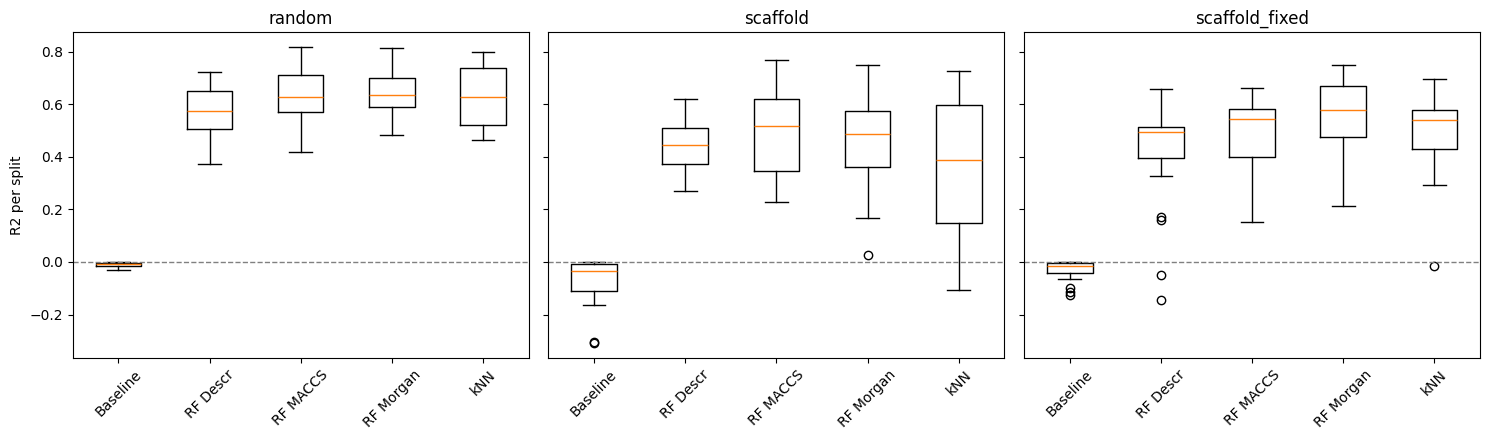

In [28]:
import matplotlib.pyplot as plt

res_all = pd.concat([pd.read_csv(f"{TAG}_model_eval_all_splits.csv"),
                     pd.read_csv(f"{TAG}_model_eval_scaffold_fixed.csv")])
d = res_all[res_all["dataset"] == "all"]
order = ["Baseline", "RF Descr", "RF MACCS", "RF Morgan", "kNN"]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for a, p in zip(ax, ["random", "scaffold", "scaffold_fixed"]):
    data = [d[(d["split_type"] == p) & (d["model"] == m_)]["R2"] for m_ in order]
    a.boxplot(data, tick_labels=order)
    a.axhline(0, color="grey", ls="--", lw=1)
    a.set_title(p)
    a.tick_params(axis="x", rotation=45)
ax[0].set_ylabel("R2 per split")
plt.tight_layout()
plt.savefig(f"{TAG}_fig_split_distributions.png", dpi=300)
plt.show()

## Summary and limitations
- On 130 public M. tuberculosis DprE1 IC50 values, models show at most a weak within-series signal and no skill on held-out scaffolds, under three validation protocols and with or without review-derived records. Nearest-neighbour correlation is 0.42 (95% bootstrap interval 0.22 to 0.57).
- BindingDB adds no independent data: all rows are ChEMBL-sourced, and its repeat rows are mostly duplicates.
- Limitations: small dataset; one paper supplies 55% of compounds; source, series and assay are confounded; almost no independent repeated measurements; Murcko scaffolds hide the nitro group; nitro flag is a crude covalent proxy; 12 compounds come from a review-like document.
- Open items: check the 7 BindingDB-only and 10 connectivity-only compounds, trace review-derived records to primary papers, literature-gap search, supervisor decision on scope.
- SHAP interpretation is on hold until a model shows predictive skill.

In [29]:
import sklearn, rdkit, scipy, matplotlib
print("pandas", pd.__version__, "| numpy", np.__version__, "| sklearn", sklearn.__version__)
print("rdkit", rdkit.__version__, "| matplotlib", matplotlib.__version__)
!pip freeze > requirements.txt

pandas 2.2.3 | numpy 2.1.3 | sklearn 1.6.1
rdkit 2026.03.6 | matplotlib 3.10.0


## 21. Primary-source sensitivity, time split and leave-one-paper-out
Declared before running. (A) Repeat 20 scaffold-grouped splits using only compounds from primary papers. (B) Time split: train on papers up to 2019, test on 2020 onward (about 20%). (C) Leave-one-paper-out for primary papers with at least 15 compounds. Metrics: R2 and Spearman. All results will be reported. Rule: if R2 and Spearman stay clearly above the baseline when whole papers are held out, the InhA signal is not just series/paper identity; if they drop toward zero, it largely is.

In [30]:
from scipy.stats import spearmanr

keep = ~m["secondary"].values
print("primary-source compounds:", keep.sum(), "of", len(keep))

doc = m["document_chembl_id"].values
yr = docs.set_index("document_chembl_id")["year"].astype(int)
cy = pd.Series(doc).map(yr).values

models = {"Baseline":  (lambda: DummyRegressor(strategy="mean"), fp_array),
          "RF Morgan": (make_rf, fp_array),
          "RF MACCS":  (make_rf, maccs_array),
          "RF Descr":  (make_rf, desc_df.values),
          "kNN":       (make_knn, X_bits)}

def score(tr, te):
    out = {}
    for name, (mk, X) in models.items():
        mdl = mk(); mdl.fit(X[tr], y[tr]); p = mdl.predict(X[te])
        rho = spearmanr(y[te], p)[0] if name != "Baseline" else float("nan")
        out[name] = (r2_score(y[te], p), rho)
    return out

# A) 20 scaffold-grouped splits, primary-source compounds only
idx = np.where(keep)[0]
sc = list(GroupShuffleSplit(n_splits=20, test_size=0.2, random_state=SEED).split(idx, y[idx], groups[idx]))
for name, (mk, X) in models.items():
    r2s = []
    for tr, te in sc:
        mdl = mk(); mdl.fit(X[idx][tr], y[idx][tr])
        r2s.append(r2_score(y[idx][te], mdl.predict(X[idx][te])))
    print(f"A) {name:10s} scaffold R2, primary only: {np.mean(r2s):.3f} +/- {np.std(r2s):.3f}")

# B) Time split
tr = np.where(keep & (cy <= 2019))[0]; te = np.where(keep & (cy >= 2020))[0]
print("\nB) Time split: train", len(tr), "| test", len(te))
for k, (r2, rho) in score(tr, te).items():
    print(f"   {k:10s} R2 = {r2:6.3f}  Spearman = {rho:6.3f}")

# C) Leave-one-paper-out for primary papers with at least 15 compounds
print()
for d in pd.Series(doc[keep]).value_counts().loc[lambda s: s >= 15].index:
    te = np.where(keep & (doc == d))[0]; tr = np.where(keep & (doc != d))[0]
    print(f"C) Held-out paper {d} (n={len(te)}, year {yr[d]})")
    for k, (r2, rho) in score(tr, te).items():
        print(f"   {k:10s} R2 = {r2:6.3f}  Spearman = {rho:6.3f}")

primary-source compounds: 312 of 345
A) Baseline   scaffold R2, primary only: -0.077 +/- 0.103
A) RF Morgan  scaffold R2, primary only: 0.585 +/- 0.162
A) RF MACCS   scaffold R2, primary only: 0.560 +/- 0.131
A) RF Descr   scaffold R2, primary only: 0.474 +/- 0.141
A) kNN        scaffold R2, primary only: 0.492 +/- 0.201

B) Time split: train 256 | test 56
   Baseline   R2 = -0.291  Spearman =    nan
   RF Morgan  R2 = -0.403  Spearman =  0.086
   RF MACCS   R2 = -0.507  Spearman =  0.318
   RF Descr   R2 = -1.093  Spearman =  0.278
   kNN        R2 =  0.097  Spearman =  0.357

C) Held-out paper CHEMBL3124857 (n=52, year 2014)
   Baseline   R2 = -13.521  Spearman =    nan
   RF Morgan  R2 = -11.114  Spearman =  0.030
   RF MACCS   R2 = -6.183  Spearman =  0.238
   RF Descr   R2 = -11.751  Spearman = -0.072
   kNN        R2 = -10.606  Spearman =  0.010
C) Held-out paper CHEMBL1137386 (n=48, year 2006)
   Baseline   R2 = -0.137  Spearman =    nan
   RF Morgan  R2 = -0.111  Spearman = -0.